# VTuber 1B: Live Chat Analytics

A directory of 32GB unified parquet file were initially preprocessed due to inconsistent

In [1]:
from pyspark.sql.functions import (
    col, count, avg, max, when, desc, lit,
    approx_count_distinct,
    broadcast,
    sum as spark_sum,
    collect_set,
    size,
    array_distinct,
    flatten,
    collect_list
)

from pyspark.sql import DataFrame
from pyspark.sql.window import Window
from pyspark.sql.functions import rank
from pyspark.sql import Row

import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("VTuber_Analytics")
    .master("local[*]") 
    .config("spark.driver.memory", "10g")
    .config(
        "spark.driver.extraJavaOptions",
        "-XX:+UseG1GC -XX:InitiatingHeapOccupancyPercent=35"
    )
    # Keep chunks small for memory safety
    .config("spark.sql.files.maxPartitionBytes", "67108864")  
    # Arrow makes the Spark -> Pandas transfer 10x to 100x faster.
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "1000")
    # Give the Driver a bit more breathing room when collecting final results for plotting.
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)

In [3]:
#Loading datasets
source = '/mnt/processed/private/msds2026/slt9a/unified_chats_2021'
source_2 = '/mnt/processed/private/msds2026/slt9a/channels_2021.csv'
chats = spark.read.parquet(source)
channels = spark.read.csv(
    source_2,
    header=True,
    inferSchema=True)

chats.createOrReplaceTempView('chats')
channels.createOrReplaceTempView('channels')

chats.printSchema()
channels.printSchema()

root
 |-- timestamp: timestamp (nullable = true)
 |-- authorChannelId: string (nullable = true)
 |-- videoId: string (nullable = true)
 |-- channelId: string (nullable = true)
 |-- bodyLength: long (nullable = true)

root
 |-- _c0: integer (nullable = true)
 |-- channelId: string (nullable = true)
 |-- name: string (nullable = true)
 |-- englishName: string (nullable = true)
 |-- affiliation: string (nullable = true)
 |-- videoCount: integer (nullable = true)



In [4]:
channels.show(5)

+---+--------------------+----------------------------+--------------------+-----------+----------+
|_c0|           channelId|                        name|         englishName|affiliation|videoCount|
+---+--------------------+----------------------------+--------------------+-----------+----------+
|  0|UCJFZiqLMntJufDCH...|   hololive ホロライブ - ...|Hololive VTuber G...|   Hololive|       509|
|  1|UCfrWoRGlawPQDQxx...|          hololive Indonesia|  Hololive Indonesia|   Hololive|        69|
|  2|UCotXwY6s8pWmuWd_...|            hololive English|    Hololive English|   Hololive|        34|
|  3|UCWsfcksUUpoEvhia...|  holostars ホロスターズ ...|  Holostars Official|   Hololive|       150|
|  4|UCp6993wxpyDPHUpa...|SoraCh. ときのそらチャンネル|         Tokino Sora|   Hololive|       667|
+---+--------------------+----------------------------+--------------------+-----------+----------+
only showing top 5 rows


In [5]:
def most_channel():
    """
    Which VTuber channels receive the most channels?
    """

    query = """
    SELECT channels.englishName as `English Name`, COUNT(*) as `Total Chats`
    FROM chats
    JOIN channels
    ON chats.channelId = channels.channelId
    GROUP BY channels.englishName
    ORDER BY `Total Chats` DESC
    LIMIT 20;
    """
    
    return spark.sql(query)

In [6]:
q1 = most_channel()
q1.show()

+----------------+-----------+
|    English Name|Total Chats|
+----------------+-----------+
|    Usada Pekora|   31144439|
|     Sakura Miko|   18542086|
|       Gawr Gura|   14632354|
| Takanashi Kiara|   13825699|
|   Oozora Subaru|   13272619|
|   Yukihana Lamy|   12801025|
|    Uruha Rushia|   12543306|
|Tsunomaki Watame|   12109778|
|  Houshou Marine|   11744882|
|   Watson Amelia|   11272410|
|          Kuzuha|   11165917|
|  Inugami Korone|   11019240|
|    Amane Kanata|    9697269|
|           Kanae|    9187275|
| Ninomae Ina’nis|    8529349|
|Shirakami Fubuki|    8512457|
|      Kiryu Coco|    8232139|
|   Mori Calliope|    8223660|
|     Fuwa Minato|    8119214|
|  Nekomata Okayu|    8070036|
+----------------+-----------+



In [7]:
def mo_stream_chats():
    """
    How many stream chats done per month of the year 2021?
    """

    query = """
    SELECT 
        DATE_FORMAT(timestamp, 'yyyy-MM') AS `year-month`,
        COUNT(*) AS total_chats
    FROM chats
    GROUP BY DATE_FORMAT(timestamp, 'yyyy-MM')
    ORDER BY `year-month`;
    """
    return spark.sql(query)

In [8]:
q2 = mo_stream_chats()
q2.show()

+----------+-----------+
|year-month|total_chats|
+----------+-----------+
|   2021-01|    1998144|
|   2021-02|   30707138|
|   2021-03|   67126793|
|   2021-04|   63446229|
|   2021-05|   75898905|
|   2021-06|   75388311|
|   2021-07|   80829747|
|   2021-08|   99281411|
|   2021-09|   87760727|
|   2021-10|   83370517|
|   2021-11|   81942259|
|   2021-12|     591577|
+----------+-----------+



/tmp/ipykernel_10866/2173068415.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


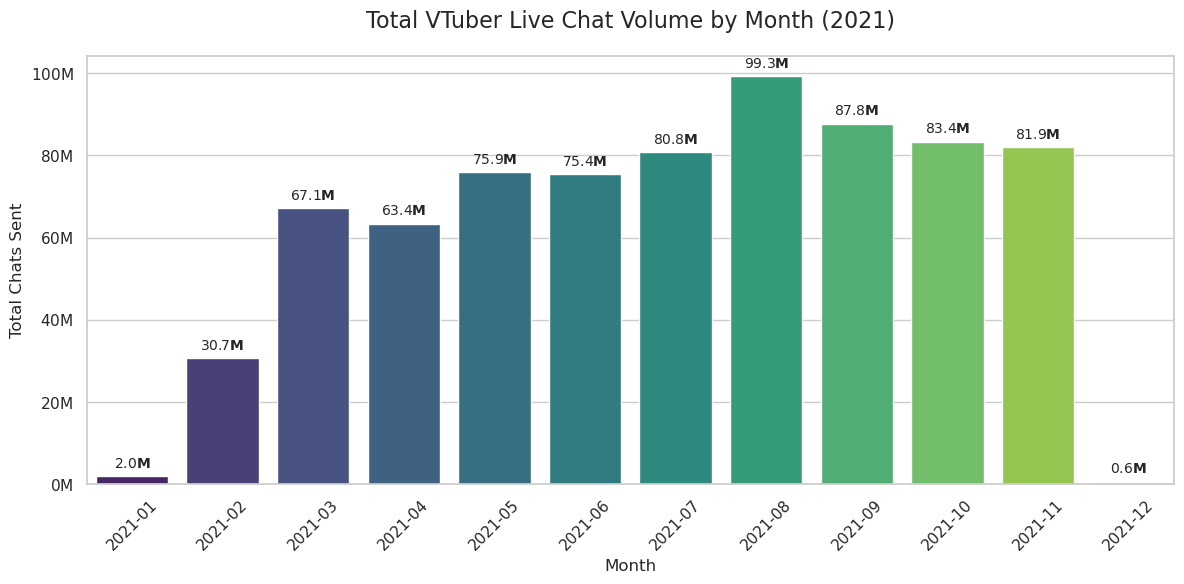

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Ensure you have the Pandas DataFrame from your Spark query
q2_df = q2.toPandas()

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the Vertical Bar Plot
# We use a color palette like 'viridis' or 'Blues_d' for a professional look
bar_plot = sns.barplot(
    data=q2_df, 
    x='year-month',
    y='total_chats',
    palette='viridis'
)

# 4. Format the Y-Axis for Big Data (Millions)
# This converts 1,000,000 to '1M'
def millions(x, pos):
    return f'${x*1e-6:,.0f}$M'

bar_plot.yaxis.set_major_formatter(ticker.FuncFormatter(millions))

# 5. Add Data Labels on top of each bar
# This makes the static plot much easier to read at a glance
for p in bar_plot.patches:
    bar_plot.annotate(
        f'${p.get_height()*1e-6:.1f}$M', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# 6. Final Aesthetic Touches
plt.title('Total VTuber Live Chat Volume by Month (2021)', fontsize=16, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Chats Sent', fontsize=12)
plt.xticks(rotation=45)

# 7. Clean display
plt.tight_layout()
plt.show()

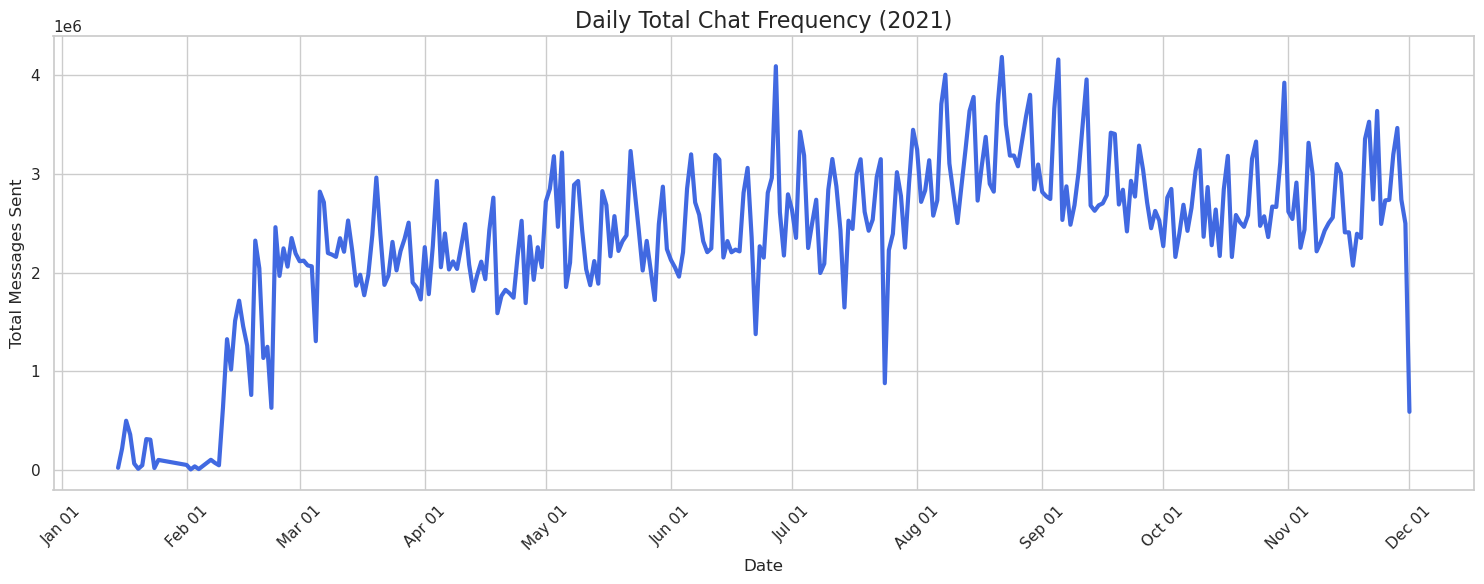

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Spark does the heavy lifting: Filter for 2021 and group by day
def daily_chats():
    """
    How does chat frequency change over time?
    """
    query = """
    SELECT DATE(timestamp) AS chat_date,
           COUNT(*) AS daily_chats
    FROM chats
    GROUP BY DATE(timestamp)
    ORDER BY chat_date;
    """
    return spark.sql(query)

# Safely collect the ~365 rows to the Driver's RAM
q3_df = daily_chats().toPandas()


# Set the theme for a professional look
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6))

# Create the line plot
line_plot = sns.lineplot(data=q3_df, x='chat_date', y='daily_chats', color='royalblue', linewidth=3)

# Improve Date Formatting on X-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d')) # Shows "Jan 01"
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())          # Tick marks at every month

plt.title('Daily Total Chat Frequency (2021)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Messages Sent', fontsize=12)

# Rotate labels so they don't overlap
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

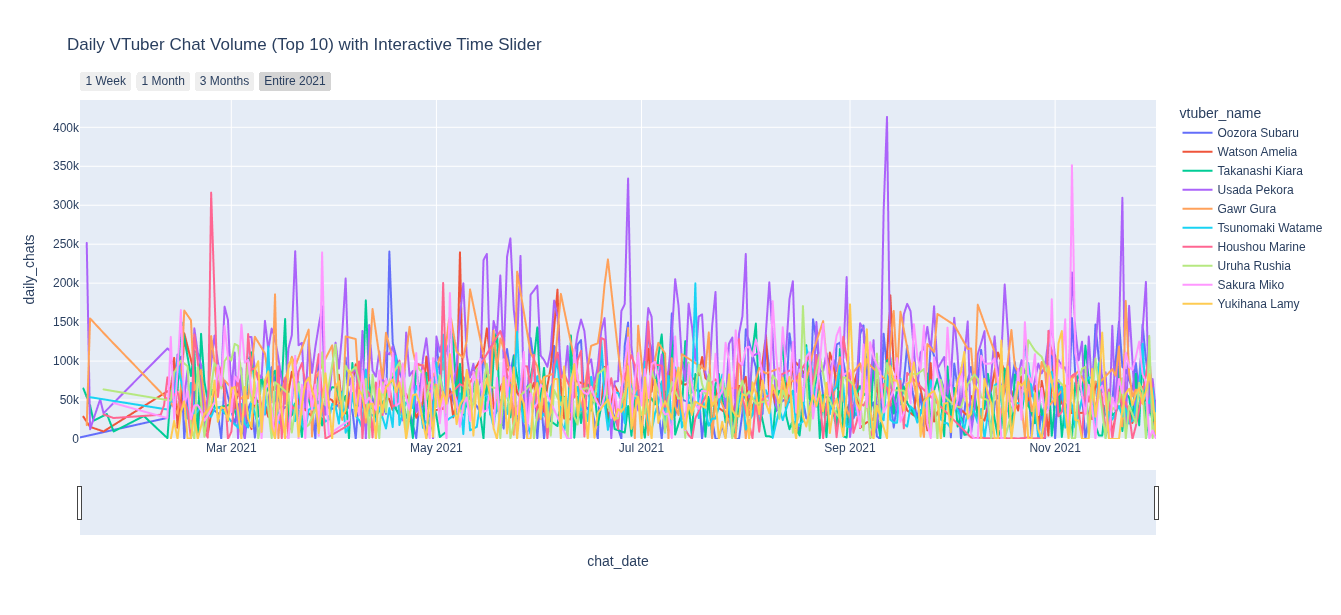

In [11]:
# 1. Spark does the heavy lifting: Find Top 10, Join, and Group

def vtuber_daily():
    """doctring"""
    
    query = """
    -- Step A: Find the Top 10 Channels by total chat volume
    WITH Top10Channels AS (
        SELECT channelId, COUNT(*) as total_chats
        FROM chats
        GROUP BY channelId
        ORDER BY total_chats DESC
        LIMIT 10
    )
    -- Step B: Join that top 10 list with the main data and channels table
    SELECT DATE(c.timestamp) AS chat_date,
           ch.englishName AS vtuber_name,
           COUNT(*) AS daily_chats
    FROM chats c
    JOIN channels ch ON c.channelId = ch.channelId
    JOIN Top10Channels t ON c.channelId = t.channelId
    GROUP BY DATE(c.timestamp), ch.englishName
    ORDER BY chat_date;
    """
    return spark.sql(query)


# 2. Collect the summarized data (roughly 365 days * 10 VTubers = ~3,650 rows)
q3_modified_df = vtuber_daily().toPandas()

# 3. Build the Plotly Line Chart
fig = px.line(
    q3_modified_df,
    x='chat_date',
    y='daily_chats',
    color='vtuber_name',
    title='Daily VTuber Chat Volume (Top 10) with Interactive Time Slider',
    width=1500,
    height=600
)

# 4. Add back your Range Slider and Quick-Select Buttons
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="1 Week", step="day", stepmode="backward"),
            dict(count=1, label="1 Month", step="month", stepmode="backward"),
            dict(count=3, label="3 Months", step="month", stepmode="backward"),
            dict(step="all", label="Entire 2021")
        ])
    )
)

# 5. Clean up the Y-axis
fig.update_yaxes(rangemode="tozero")

# 6. Display in Colab
display(fig)

In [12]:
vtuber_daily().show(50)

+----------+----------------+-----------+
| chat_date|     vtuber_name|daily_chats|
+----------+----------------+-----------+
|2021-01-15|   Oozora Subaru|       2015|
|2021-01-16|   Watson Amelia|      28653|
|2021-01-16| Takanashi Kiara|      64832|
|2021-01-17|    Usada Pekora|     251729|
|2021-01-17|       Gawr Gura|      17713|
|2021-01-18|   Watson Amelia|      15517|
|2021-01-18|Tsunomaki Watame|      53645|
|2021-01-18|       Gawr Gura|     154646|
|2021-01-18|    Usada Pekora|      12474|
|2021-01-18| Takanashi Kiara|      43202|
|2021-01-19| Takanashi Kiara|      23299|
|2021-01-21|    Usada Pekora|      50936|
|2021-01-22|  Houshou Marine|      31455|
|2021-01-22|   Watson Amelia|       9709|
|2021-01-22|    Usada Pekora|      33095|
|2021-01-22|    Uruha Rushia|      63625|
|2021-01-23| Takanashi Kiara|      31974|
|2021-01-23|       Gawr Gura|     131495|
|2021-01-25| Takanashi Kiara|       9697|
|2021-01-25|  Houshou Marine|      26947|
|2021-01-25|     Sakura Miko|     

In [13]:
# Are longer chats more common in some streams or channels?

def long_chat():
    """
    Are longer chats more common in some streams or channels?
    """
    query = """
    SELECT ch.englishName AS `English Name`,
        AVG(c.bodyLength) AS avg_chat_length,
        COUNT(*) AS total_chats
    FROM chats c
    JOIN channels ch
    ON c.channelId = ch.channelId
    GROUP BY ch.englishName
    HAVING total_chats > 5000  -- Filters out low-chat anomalies
    ORDER BY avg_chat_length DESC;
    """
    return spark.sql(query)

In [14]:
long_chat().show(20, truncate=False)

+---------------+------------------+-----------+
|English Name   |avg_chat_length   |total_chats|
+---------------+------------------+-----------+
|Walfie         |34.25545092586741 |15823      |
|Europa         |30.256508875739645|6760       |
|Ushio Ebi      |27.13420306398048 |222521     |
|Pipkin Pippa   |26.941926459667343|335299     |
|Orla Gan Ceann |26.629163400680884|85477      |
|Kaga Oren      |25.966904345486345|22299      |
|Tsurugi Nen    |25.54158964879852 |7033       |
|Cecile         |25.038280616382806|24660      |
|Yazaki Kallin  |25.01006081654584 |128419     |
|FruFru VTubers |24.907278733340927|17558      |
|Jaret Fajrianto|24.826221939181657|12562      |
|Shee Icho      |24.79529848937717 |61895      |
|Fujikura Uruka |24.738833804454725|161671     |
|Tetsuya Kazune |24.548014359434596|26742      |
|Mana Renewal   |24.499610776369554|360975     |
|Kyria          |24.15782109345106 |175097     |
|Rinkou Ashelia |24.148406902441177|135836     |
|Kitsui Akira   |23.

In [15]:
# Querying Affiliations
def affiliations():
    """
    Just Getting list of affiliation
    """

    query = """
    SELECT DISTINCT(affiliation)
    FROM channels;
    """
    return spark.sql(query)

In [16]:
affiliations().toPandas()

,affiliation
0,Snacknili
1,H.Live
2,Axel-V
3,WACTOR
4,Shinsougumi
5,VSpo
6,Riot Music
7,Masquerade
8,Emoechi
9,ViViD


### Basic Aggregation: Total Message Volume by Affiliation

Business Objective: Get a __macro-level__ view of which VTuber agencies drive the highest total volume of chat interactions across all their talents.

Concepts: `INNER JOIN`, `COUNT`, `GROUP BY`, `ORDER BY`

In [17]:
def x5():
    query = """
    SELECT 
    ch.affiliation, 
    COUNT(1) AS total_messages
    FROM chats c
    JOIN channels ch ON c.channelId = ch.channelId
    WHERE ch.affiliation IS NOT NULL
    GROUP BY ch.affiliation
    ORDER BY total_messages DESC;
    """
    return spark.sql(query)

In [18]:
x5().show()

+-----------------+--------------+
|      affiliation|total_messages|
+-----------------+--------------+
|         Hololive|     343361344|
|        Nijisanji|     228736400|
|     Independents|      55363350|
|           774inc|      29060655|
|            .LIVE|      13396002|
|         Nori Pro|      10915298|
|             VSpo|       8898313|
|           WACTOR|       7878021|
|            ReAcT|       4510546|
|        Neo-Porte|       4062434|
|             VOMS|       3787485|
|           VShojo|       3739429|
|            PRISM|       3482182|
|       Masquerade|       3187352|
|           ProPro|       2396761|
|       SquareLive|       2278501|
|            ViViD|       1731292|
|Production Kawaii|       1564174|
|          GuildCQ|       1423863|
|Aogiri Highschool|       1177198|
+-----------------+--------------+
only showing top 20 rows


### Basic Filtering: Top 10 Most Active VTubers in a Specific Agency

Business Objective: Drill down into a specific agency (e.g., **Nijisanji**) to identify their top performers based purely on standard text chat engagement.

Concepts: `WHERE` filtering with multiple conditions

In [23]:
def x6():
    query = """
    SELECT
        ch.englishName,
        COUNT(c.channelId) as count
    FROM
        chats c
    JOIN
        channels ch ON c.channelId = ch.channelId
    WHERE 
        ch.affiliation = 'Nijisanji'
    GROUP BY
        ch.englishName
    ORDER BY
        count DESC
    LIMIT 10;
    """
    return spark.sql(query)

In [24]:
x6().show()

+----------------+--------+
|     englishName|   count|
+----------------+--------+
|          Kuzuha|11165917|
|           Kanae| 9187275|
|     Fuwa Minato| 8119214|
|         Ibrahim| 8037235|
|   Yuuki Chihiro| 5875431|
|Furen E Lustario| 5196631|
|     Nui Sociere| 5137712|
|   Kagami Hayato| 4745107|
|   Elira Pendora| 4514083|
|    Leos Vincent| 4453654|
+----------------+--------+



### Date Truncation: Daily Chat Volume Comparison Among Major Agencies

Business Objective: Compare the daily engagement trends of the major agencies side-by-side to see who "won" specific days (e.g., during major 3D live events or agency-wide tournaments).

Concepts: `TO_DATE()`, Time-based grouping across multiple dimensions

In [25]:
def x7():
    """ docstring hehe"""
    
    query = """
    SELECT 
        ch.affiliation, 
        TO_DATE(c.timestamp) AS stream_date,
        COUNT(1) AS daily_messages
    FROM
        chats c
    JOIN
        channels ch ON c.channelId = ch.ChannelId
    WHERE
        ch.affiliation IN ('Hololive', 'Nijisanji', 'VShojo')
    GROUP BY
        ch.affiliation, 
        TO_DATE(c.timestamp)
    ORDER BY
        stream_date ASC, 
        daily_messages DESC;
    """
    return spark.sql(query)

In [26]:
x7().show()

+-----------+-----------+--------------+
|affiliation|stream_date|daily_messages|
+-----------+-----------+--------------+
|   Hololive| 2021-01-15|         25083|
|   Hololive| 2021-01-16|        220849|
|   Hololive| 2021-01-17|        501428|
|   Hololive| 2021-01-18|        362902|
|   Hololive| 2021-01-19|         67864|
|   Hololive| 2021-01-20|         15177|
|   Hololive| 2021-01-21|         50936|
|   Hololive| 2021-01-22|        315740|
|   Hololive| 2021-01-23|        310307|
|   Hololive| 2021-01-24|         22888|
|   Hololive| 2021-01-25|        104970|
|   Hololive| 2021-02-01|         53981|
|   Hololive| 2021-02-02|          8859|
|   Hololive| 2021-02-03|         39834|
|   Hololive| 2021-02-04|         12087|
|   Hololive| 2021-02-07|        106372|
|   Hololive| 2021-02-08|         75385|
|   Hololive| 2021-02-09|         50776|
|   Hololive| 2021-02-10|        636932|
|   Hololive| 2021-02-11|       1326800|
+-----------+-----------+--------------+
only showing top

### Common Table Expressions (CTE): Unique Audience Size per Affiliation

Business Objective: Message volume can be skewed by chat spammers. This query calculates the unique number of individual viewers chatting within each agency's ecosystem.

Concepts: `WITH (CTE), COUNT(DISTINCT ...)`

In [28]:
def x8():
    query = """
    WITH AgencyAudience AS (
        SELECT 
            ch.affiliation, 
            c.authorChannelId
        FROM
            chats c
        JOIN
            channels ch ON c.channelId = ch.channelId
        WHERE
            ch.affiliation IS NOT NULL
        -- Grouping first to reduce the size of the dataset before the distinct count
        GROUP BY
            ch.affiliation,
            c.authorChannelId
    )
    SELECT 
        affiliation,
        COUNT(DISTINCT authorChannelId) AS unique_chatters
    FROM
        AgencyAudience
    GROUP BY
        affiliation
    ORDER BY
        unique_chatters DESC;
    """
    return spark.sql(query)

In [29]:
x8().show(10)

+------------+---------------+
| affiliation|unique_chatters|
+------------+---------------+
|    Hololive|        2342738|
|   Nijisanji|        1182972|
|Independents|        1036025|
|      774inc|         161602|
|   Neo-Porte|         154483|
|        VSpo|         152660|
|      VShojo|         140971|
|    Nori Pro|         108887|
|        VOMS|          96529|
|      WACTOR|          84959|
+------------+---------------+
only showing top 10 rows


In [30]:
x8().toPandas()

,affiliation,unique_chatters
0,Hololive,2342738
1,Nijisanji,1182972
2,Independents,1036025
3,774inc,161602
4,Neo-Porte,154483
5,VSpo,152660
6,VShojo,140971
7,Nori Pro,108887
8,VOMS,96529
9,WACTOR,84959


### Window Functions: Ranking Top VTubers Within Each Affiliation

Business Objective: Create an internal leaderboard for every agency. Instead of comparing an indie to a massive Hololive star, this ranks talents strictly against their direct agency peers.
    
Concepts: `RANK() OVER(PARTITION BY ... ORDER BY ...)`

In [37]:
def x9():
    """ docstring """
    query = """
    WITH AgencyStats AS (
        SELECT 
            ch.affiliation,
            ch.englishName,
            COUNT(1) AS chat_volume
        FROM 
            chats c 
        JOIN 
            channels ch ON c.channelId = ch.channelId
        WHERE 
            ch.affiliation IS NOT NULL
        GROUP BY 
            ch.affiliation, 
            ch.englishName
    )
    SELECT 
        affiliation, 
        englishName, 
        chat_volume,
        RANK() OVER (PARTITION BY affiliation ORDER BY chat_volume DESC) as rank_in_agency
    FROM
        AgencyStats
    ORDER BY
        affiliation ASC, 
        rank_in_agency ASC;
    """

    return spark.sql(query)

In [38]:
x9().toPandas()

,affiliation,englishName,chat_volume,rank_in_agency
0,.LIVE,Kakyouin Chieri,4627495,1
1,.LIVE,Kagura Suzu,2257923,2
2,.LIVE,Carro Pino,1393998,3
3,.LIVE,Yamato Iori,1355469,4
4,.LIVE,Mokota Mememe,815283,5
...,...,...,...,...
883,Yume Reality,Nemutaka Yuta,105624,2
884,Yume Reality,Tsuyu Hortenshia,83564,3
885,Yume Reality,Cerys Lebelia,81698,4
886,Yuni Create,Akatsuki Yuni,453336,1


### Window Functions: Cumulative Engagement Growth by Affiliation

Business Objective: Visualize the compounding growth of agencies over time by tracking their running total of chat messages day over day.

Concepts: `SUM() OVER(... ROWS BETWEEN UNBOUNDED PRECEDING...)`

In [39]:
def x10():
    """ dock istring """
    query = """
    WITH DailyAgencyVolume AS (
        SELECT 
            ch.affiliation, 
            TO_DATE(c.timestamp) AS chat_date, 
            COUNT(1) as daily_volume
        FROM 
            chats c 
        JOIN 
            channels ch ON c.channelId = ch.channelId
        WHERE 
            ch.affiliation IS NOT NULL
        GROUP BY 
            ch.affiliation,
            TO_DATE(c.timestamp)
    )
    SELECT 
        affiliation, 
        chat_date, 
        daily_volume,
        SUM(daily_volume) OVER (
            PARTITION BY affiliation 
            ORDER BY chat_date 
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as cumulative_volume
    FROM 
        DailyAgencyVolume
    ORDER BY 
        affiliation, 
        chat_date;
    """

    return spark.sql(query)

In [40]:
x10().show()

+-----------+----------+------------+-----------------+
|affiliation| chat_date|daily_volume|cumulative_volume|
+-----------+----------+------------+-----------------+
|      .LIVE|2021-02-18|       25477|            25477|
|      .LIVE|2021-02-19|       50790|            76267|
|      .LIVE|2021-02-20|        6980|            83247|
|      .LIVE|2021-02-21|        2897|            86144|
|      .LIVE|2021-02-22|       14046|           100190|
|      .LIVE|2021-02-23|       11693|           111883|
|      .LIVE|2021-02-24|       67185|           179068|
|      .LIVE|2021-02-25|       54890|           233958|
|      .LIVE|2021-02-26|       18275|           252233|
|      .LIVE|2021-02-27|       69066|           321299|
|      .LIVE|2021-02-28|       65023|           386322|
|      .LIVE|2021-03-01|       15150|           401472|
|      .LIVE|2021-03-02|       40705|           442177|
|      .LIVE|2021-03-03|       23383|           465560|
|      .LIVE|2021-03-04|       24106|           

### Time-Series: 7-Day Moving Average of Unique Active Chatters per Agency

Business Objective: Smooth out the volatility of single-day massive events to understand the true underlying **daily active user** (DAU) base supporting each affiliation over time.

Concepts: Time-series smoothing, Window Functions with `ROWS BETWEEN`

In [43]:
def x11():
    """ dcstrng """
    query = """
    WITH DailyActiveChatters AS (
    SELECT 
        ch.affiliation, 
        TO_DATE(c.timestamp) AS chat_date, 
        COUNT(DISTINCT c.authorChannelId) as daily_active_users
    FROM 
        chats c
    JOIN 
        channels ch ON c.channelId = ch.channelId
    WHERE 
        ch.affiliation IS NOT NULL
    GROUP BY 
        ch.affiliation,
        TO_DATE(c.timestamp)
    )
    SELECT 
    affiliation, 
    chat_date, 
    daily_active_users,
    ROUND(AVG(daily_active_users) OVER (
        PARTITION BY affiliation 
        ORDER BY chat_date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS 7_day_mau
    FROM 
    DailyActiveChatters
    ORDER BY 
    affiliation, 
    chat_date;
    """
    return spark.sql(query)

In [45]:
x11().toPandas()

,affiliation,chat_date,daily_active_users,7_day_mau
0,.LIVE,2021-02-18,1215,1215.00
1,.LIVE,2021-02-19,1695,1455.00
2,.LIVE,2021-02-20,457,1122.33
3,.LIVE,2021-02-21,210,894.25
4,.LIVE,2021-02-22,509,817.20
...,...,...,...,...
9350,Yuni Create,2021-11-25,286,296.00
9351,Yuni Create,2021-11-26,1,235.14
9352,Yuni Create,2021-11-28,4,169.57
9353,Yuni Create,2021-11-29,237,203.00


### Advanced Aggregation: Identifying the Hype Peaks (Top 3 Peak BPM per Agency)

Business Objective: Find out which 3 specific streams/moments generated the absolute fastest chat velocity (messages per minute) for each agency.
    
Concepts: `DATE_TRUNC('minute', ...)`, **Nested Subqueries** with **Window Functions**

In [47]:
def x12():
    """ dxstrng """

    query = """ WITH MinuteAggregations AS (
        SELECT 
            ch.affiliation, 
            ch.englishName, 
            DATE_TRUNC('minute', c.timestamp) AS chat_minute, 
            COUNT(1) AS messages_per_minute
        FROM 
            chats c 
        JOIN 
            channels ch ON c.channelId = ch.channelId
        WHERE 
            ch.affiliation IS NOT NULL
        GROUP BY 
            ch.affiliation, 
            ch.englishName, 
            DATE_TRUNC('minute', c.timestamp)
    ),
    AgencyPeakVelocity AS (
        SELECT 
            affiliation, 
            englishName, 
            MAX(messages_per_minute) AS peak_bpm
        FROM 
            MinuteAggregations
        GROUP BY 
            affiliation, 
            englishName
    )
    SELECT 
        affiliation, 
        englishName, 
        peak_bpm
    FROM (
        SELECT 
            affiliation, 
            englishName, 
            peak_bpm,
            RANK() OVER (PARTITION BY affiliation ORDER BY peak_bpm DESC) as rnk
        FROM 
            AgencyPeakVelocity
    ) ranked_peaks
    WHERE 
        rnk <= 3
    ORDER BY 
        affiliation, 
        rnk;
    """

    return spark.sql(query)

In [48]:
x12().toPandas()

,affiliation,englishName,peak_bpm
0,.LIVE,Kongou Iroha,2024
1,.LIVE,Kitakami Futaba,1848
2,.LIVE,Yaezawa Natori,1600
3,774inc,Hashiba Natsumi,1239
4,774inc,Suou Patra,1190
...,...,...,...
143,Yume Reality,Nekoyama Sena,789
144,Yume Reality,Nemutaka Yuta,399
145,Yume Reality,Cerys Lebelia,299
146,Yuni Create,Mochiduki Himari,684
